### ============================================================
# Bank Dataset Cleaning and Visualization
### ============================================================

## 1️⃣ Import Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

## 2️⃣ Load Dataset

In [2]:
df = pd.read_csv("bank.csv")
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   age         job  marital  education  balance housing loan  contact  day  \
0   59      admin.  married  secondary     2343     yes   no  unknown    5   
1   56      admin.  married  secondary       45      no   no  unknown    5   
2   41  technician  married  secondary     1270     yes   no  unknown    5   
3   55    services  married  secondary     2476     yes   no  unknown    5   
4   54      admin.  married   tertiary      184      no   no  unknown    5   

  month  duration  campaign  pdays  previous deposit  
0   may      1042         1     -1         0     yes  
1   may      1467         1     -1         0     yes  
2   may      1389         1     -1         0     yes  
3   may       579         1     -1         0     yes  
4   may       673         2     -1         0     yes  


## 3️⃣ Drop Unnecessary Columns

In [3]:
drop_cols = ["duration", "day", "month", "pdays", "contact", "previous"]
df.drop(columns=drop_cols, inplace=True)

## 4️⃣ Check Data Types and Missing Values

In [4]:
def chk_types(data):
    """Returns data types and number of unique values per column"""
    dtypes = data.dtypes
    n_uniques = data.nunique()
    return pd.DataFrame({"Dtype": dtypes, "Num_Uniques": n_uniques}).T

In [5]:
def chk_null(data):
    """Returns count and percentage of missing values per column"""
    null = data.isnull().sum()
    ratio = (null / data.shape[0]) * 100
    return pd.DataFrame({"Null Count": null, "Null %": ratio.round(2)}).T

In [6]:
print("\nData types and unique values:")
print(chk_types(df))
print("\nMissing values check:")
print(chk_null(df))


Data types and unique values:
               age     job marital education balance housing    loan campaign  \
Dtype        int64  object  object    object   int64  object  object    int64   
Num_Uniques     76      12       3         4    3805       2       2       36   

            deposit  
Dtype        object  
Num_Uniques       2  

Missing values check:
            age  job  marital  education  balance  housing  loan  campaign  \
Null Count  0.0  0.0      0.0        0.0      0.0      0.0   0.0       0.0   
Null %      0.0  0.0      0.0        0.0      0.0      0.0   0.0       0.0   

            deposit  
Null Count      0.0  
Null %          0.0  


## 5️⃣ Convert Object Columns to Category

In [7]:
cat_cols = ["job", "marital", "education", "housing", "loan", "deposit"]
for col in cat_cols:
    df[col] = df[col].astype('category')

In [8]:
chk_types(df)

,age,job,marital,education,balance,housing,loan,campaign,deposit
Dtype,int64,category,category,category,int64,category,category,int64,category
Num_Uniques,76,12,3,4,3805,2,2,36,2


## 6️⃣ Remove Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(313)

In [10]:
df.drop_duplicates(inplace=True)


## 7️⃣ Handle Numeric Outliers (IQR Capping)

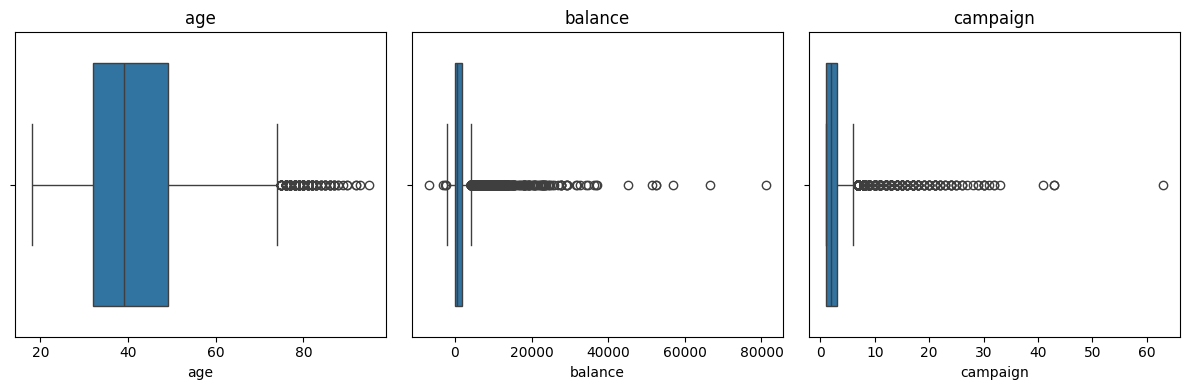

In [11]:
num_cols = ["age", "balance", "campaign"]
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col], orient="h")
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
num_cols = ["age", "balance", "campaign"]
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)  # Cap outliers at fence values

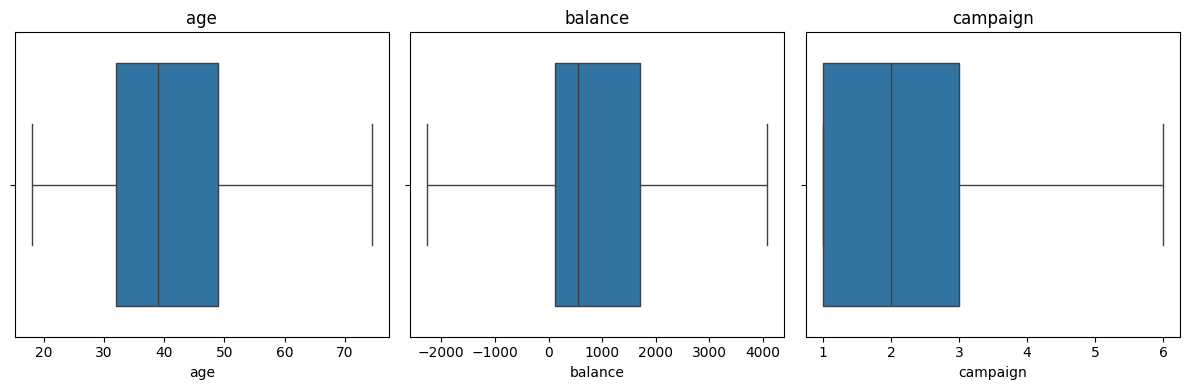

In [13]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col], orient="h")
    plt.title(col)
plt.tight_layout()
plt.show()

## 9️⃣ Visualize Relationships Between Features and Target

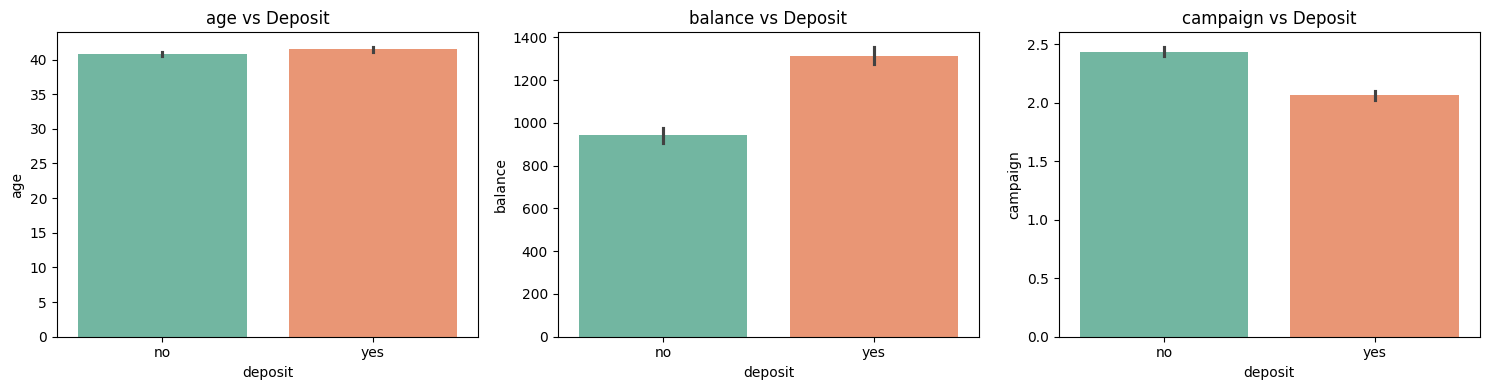

In [14]:
num_cols = ["age", "balance", "campaign"]

plt.figure(figsize=(15,4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(x="deposit", y=col, data=df, palette="Set2")
    plt.title(f"{col} vs Deposit")
plt.tight_layout()
plt.show()


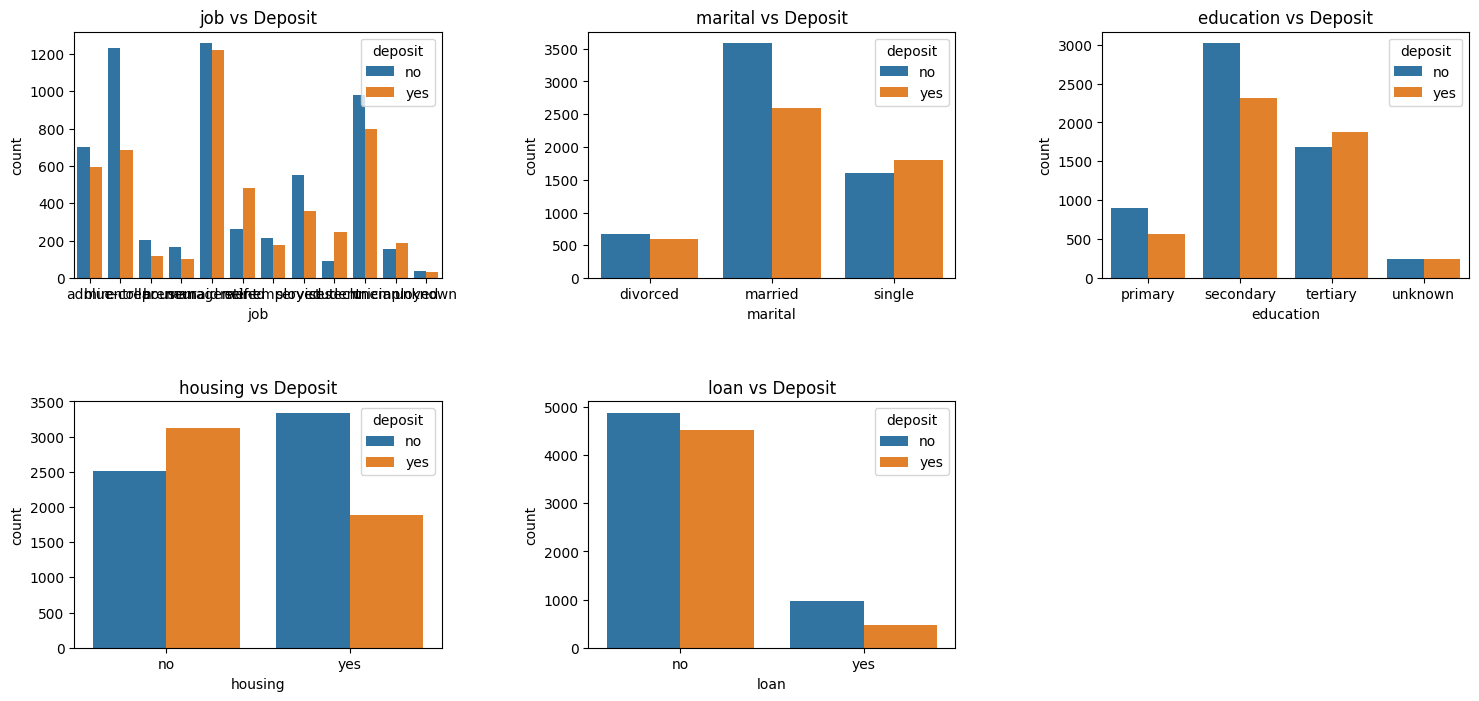

In [15]:
cat_cols_no_target = ["job", "marital", "education", "housing", "loan"]

plt.figure(figsize=(18,8))
for i, col in enumerate(cat_cols_no_target):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, hue="deposit", data=df)
    plt.title(f"{col} vs Deposit")
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

## 10️⃣ Split, Normalize, and Encode the Bank Dataset

### 10.1️⃣ Split the Dataset

In [16]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 10.2️⃣ Normalize Numeric Features

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Numeric columns
num_cols = ["age", "balance", "campaign"]

# Initialize scaler
scaler = MinMaxScaler()

# Fit on training set only
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply same transformation to test set
X_test[num_cols] = scaler.transform(X_test[num_cols])


### 10.3️⃣ Encode Categorical Features

### 3.1️⃣ Ordinal Encode Education (including unknown)

In [23]:
from sklearn.preprocessing import OrdinalEncoder

# Replace 'unknown' with most frequent education
most_freq = X_train["education"].mode()[0]
X_train["education"] = X_train["education"].replace("unknown", most_freq)
X_test["education"] = X_test["education"].replace("unknown", most_freq)

# Then use original OrdinalEncoder
ordinal_enc = OrdinalEncoder(categories=[["primary", "secondary", "tertiary"]])
X_train["education_enc"] = ordinal_enc.fit_transform(X_train[["education"]])
X_test["education_enc"] = ordinal_enc.transform(X_test[["education"]])

# Drop original column
X_train = X_train.drop("education", axis=1)
X_test = X_test.drop("education", axis=1)


### 3.2️⃣ Binary Mapping for Housing & Loan

In [25]:
binary_cols = ["housing", "loan"]
for col in binary_cols:
    X_train[col] = X_train[col].map({"yes": 1, "no": 0})
    X_test[col] = X_test[col].map({"yes": 1, "no": 0})


### 3.3️⃣ One-Hot Encode Nominal Features (job & marital)

In [26]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

nominal_cols = ["job", "marital"]
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_nominal = encoder.fit_transform(X_train[nominal_cols])
X_test_nominal = encoder.transform(X_test[nominal_cols])

# Convert to DataFrame
X_train_nominal = pd.DataFrame(X_train_nominal, columns=encoder.get_feature_names_out(nominal_cols), index=X_train.index)
X_test_nominal = pd.DataFrame(X_test_nominal, columns=encoder.get_feature_names_out(nominal_cols), index=X_test.index)

# Drop original nominal columns and concatenate encoded
X_train_final = pd.concat([X_train.drop(nominal_cols, axis=1), X_train_nominal], axis=1)
X_test_final = pd.concat([X_test.drop(nominal_cols, axis=1), X_test_nominal], axis=1)


### 10.4️⃣ Encode Target

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_final = le.fit_transform(y_train)
y_test_final = le.transform(y_test)


In [29]:
X_train_final

,age,balance,housing,loan,campaign,education_enc,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single
8626,0.212389,0.377366,1,0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5767,0.637168,0.360016,0,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2892,0.106195,0.393297,0,0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4751,0.247788,0.496451,1,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3467,0.407080,0.356230,0,0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10969,0.407080,0.356230,0,0,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4096,0.407080,0.368691,0,0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4051,0.442478,0.356230,0,0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4636,0.176991,1.000000,0,1,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
